In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from geodesiq import *

In [3]:
# ----- Define Hamiltonian and its gradient -----
def H_fun(x, z):
    return np.array([[z, x], [x, -z]])


def H_partial(x, z):
    return np.array([[1, 0], [0, -1]])


hamiltonian = Hamiltonian(H_fun, H_partial)

# ----- Set system and control parameters -----
alpha = 3
beta = 3
x = 1
z0 = -10
zf = -z0

hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=zf, initial_state=0, alpha=alpha, beta=beta)

# ----- Solve for optimal pulse -----
hamiltonian.solve_problem(pulse_accuracy=int(1e6))

## Plotting pulse

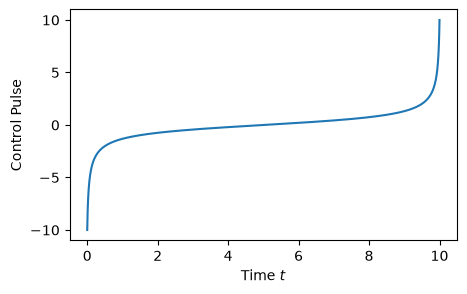

In [4]:
total_time = 10
pulse = hamiltonian.synthesize_pulse(duration=total_time)
fig, ax = hamiltonian.synthesize_pulse(duration=total_time, method='plot', pulse_kwargs={'show': True});

## Discretized pulse

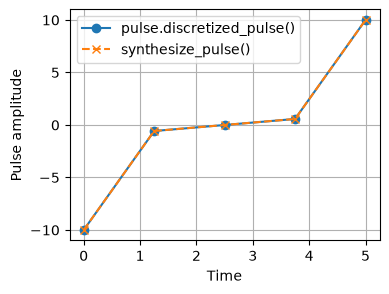

In [14]:
total_time = 5
pulse = hamiltonian.synthesize_pulse(duration=total_time)

steps = 5
discretized_pulse = pulse.discretized_pulse(linear_steps=steps)
discretized_pulse_direct = hamiltonian.synthesize_pulse(duration=total_time, method='discretized',
                                                        pulse_kwargs={'linear_steps': steps})

t1, p1 = discretized_pulse
t2, p2 = discretized_pulse_direct

plt.figure(figsize=(4, 3))

# Plot both to verify they match
plt.plot(t1, p1, 'o-', label='pulse.discretized_pulse()')
plt.plot(t2, p2, 'x--', label='synthesize_pulse()')

plt.xlabel("Time")
plt.ylabel("Pulse amplitude")
plt.legend()
plt.grid(True);

## Filtered pulse

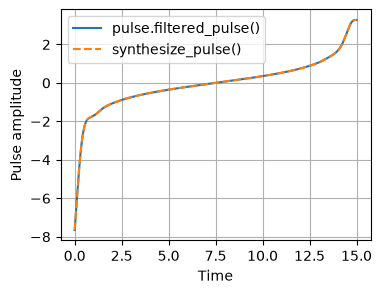

In [31]:
total_time = 15
freq_cut = 1

pulse = hamiltonian.synthesize_pulse(duration=total_time)
filtered_pulse = pulse.filtered_pulse(freq_cut)
filtered_pulse_direct = hamiltonian.synthesize_pulse(duration=total_time, method='filtered', pulse_args=(freq_cut,))

plt.figure(figsize=(4, 3))

# Plot both to verify they match
plt.plot(*filtered_pulse, '-', label='pulse.filtered_pulse()')
plt.plot(*filtered_pulse_direct, '--', label='synthesize_pulse()')

plt.xlabel("Time")
plt.ylabel("Pulse amplitude")
plt.legend()
plt.grid(True);

## Fourier spectrum

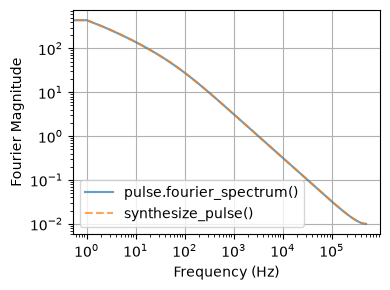

In [20]:
total_time = 1
pulse = hamiltonian.synthesize_pulse(duration=total_time)
fourier = pulse.fourier_spectrum()
fourier_direct = hamiltonian.synthesize_pulse(duration=total_time, method='fourier')

freq1, mag1 = fourier
freq2, mag2 = fourier_direct

plt.figure(figsize=(4, 3))

plt.plot(freq1, mag1, label='pulse.fourier_spectrum()', alpha=0.7)
plt.plot(freq2, mag2, '--', label='synthesize_pulse()', alpha=0.7)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier Magnitude")
plt.legend()
plt.grid(True)

plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.show()


# Export pulse

In [31]:
total_time = 10
pulse = hamiltonian.synthesize_pulse(duration=total_time)
pulse.export_pulse(filename='pulse_data', file_extension='npy', overwrite=True)

[geodesiq] File saved as 'pulse_data.npy' type.
